##### Using the dataset,predict lung cancer using K Nearest Neighbors, Naive Bayes, Random Forest, Decision Tree and ANN. Comment on your analysis.

#### 1.DATA PREPROCESSING:

##### (i)First, let's import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

##### (ii)Importing and analysing the given data

In [2]:
df=pd.read_csv('lung_cancer_prediction.csv') #data imported

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     59 non-null     int64
 1   Smokes  59 non-null     int64
 2   AreaQ   59 non-null     int64
 3   Alkhol  59 non-null     int64
 4   Result  59 non-null     int64
dtypes: int64(5)
memory usage: 2.4 KB


In [3]:
df.head() #To have a brief analysis about what kind of data it is and what are the features which are Name, Surname, Age, Smokes, AreaQ and Alkhol

,Name,Surname,Age,Smokes,AreaQ,Alkhol,Result
0,John,Wick,35,3,5,4,1
1,John,Constantine,27,20,2,5,1
2,Camela,Anderson,30,0,5,2,0
3,Alex,Telles,28,0,8,1,0
4,Diego,Maradona,68,4,5,6,1


In [4]:
#Checking for any null values
df.isnull().sum() #Output shows no null values

Name       0
Surname    0
Age        0
Smokes     0
AreaQ      0
Alkhol     0
Result     0
dtype: int64

#### 2.Classification of data into input and output:

In [6]:
x #input

array([['John', 'Wick', 35, 3, 5, 4],
       ['John', 'Constantine', 27, 20, 2, 5],
       ['Camela', 'Anderson', 30, 0, 5, 2],
       ['Alex', 'Telles', 28, 0, 8, 1],
       ['Diego', 'Maradona', 68, 4, 5, 6],
       ['Cristiano', 'Ronaldo', 34, 0, 10, 0],
       ['Mihail', 'Tal', 58, 15, 10, 0],
       ['Kathy', 'Bates', 22, 12, 5, 2],
       ['Nicole', 'Kidman', 45, 2, 6, 0],
       ['Ray', 'Milland', 52, 18, 4, 5],
       ['Fredric', 'March', 33, 4, 8, 0],
       ['Yul', 'Brynner', 18, 10, 6, 3],
       ['Joan', 'Crawford', 25, 2, 5, 1],
       ['Jane', 'Wyman', 28, 20, 2, 8],
       ['Anna', 'Magnani', 34, 25, 4, 8],
       ['Katharine ', 'Hepburn', 39, 18, 8, 1],
       ['Katharine ', 'Hepburn', 42, 22, 3, 5],
       ['Barbra', 'Streisand', 19, 12, 8, 0],
       ['Maggie ', 'Smith', 62, 5, 4, 3],
       ['Glenda ', 'Jackson', 73, 10, 7, 6],
       ['Jane ', 'Fonda', 55, 15, 1, 3],
       ['Maximilian ', 'Schell', 33, 8, 8, 1],
       ['Gregory ', 'Peck', 22, 20, 6, 2],
       ['S

In [7]:
y #output

array([1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0])

In [8]:
#But for the prediction of the lungcancer we donot require a persons name and surname as they donot affect the cause that is 'lung cancer'.
#So, let's drop name and surname
df=df.drop(columns=['Name','Surname'])
df

,Age,Smokes,AreaQ,Alkhol,Result
0,35,3,5,4,1
1,27,20,2,5,1
2,30,0,5,2,0
3,28,0,8,1,0
4,68,4,5,6,1
5,34,0,10,0,0
6,58,15,10,0,0
7,22,12,5,2,0
8,45,2,6,0,0
9,52,18,4,5,1


In [12]:
# We know that except the last column every other column is input and the last column is the output. So, lets fetch input(x) and output(y).
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [13]:
x #input

array([[35,  3,  5,  4],
       [27, 20,  2,  5],
       [30,  0,  5,  2],
       [28,  0,  8,  1],
       [68,  4,  5,  6],
       [34,  0, 10,  0],
       [58, 15, 10,  0],
       [22, 12,  5,  2],
       [45,  2,  6,  0],
       [52, 18,  4,  5],
       [33,  4,  8,  0],
       [18, 10,  6,  3],
       [25,  2,  5,  1],
       [28, 20,  2,  8],
       [34, 25,  4,  8],
       [39, 18,  8,  1],
       [42, 22,  3,  5],
       [19, 12,  8,  0],
       [62,  5,  4,  3],
       [73, 10,  7,  6],
       [55, 15,  1,  3],
       [33,  8,  8,  1],
       [22, 20,  6,  2],
       [44,  5,  8,  1],
       [77,  3,  2,  6],
       [21, 20,  5,  3],
       [37, 15,  6,  2],
       [34, 12,  8,  0],
       [55, 20,  1,  4],
       [40, 20,  2,  7],
       [36, 13,  5,  2],
       [56, 20,  3,  3],
       [47, 15,  1,  8],
       [62, 25,  3,  4],
       [26, 10,  7,  2],
       [25, 20,  8,  2],
       [59, 20,  3,  4],
       [62, 15,  5,  5],
       [33, 25,  8,  2],
       [37, 10,  5,  3],


In [14]:
y #output

array([1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0])

#### 3. Classification of the data into test and train:

In [15]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2) 
# This splits the data into train and test and test_size ensures that 20% of data is used for testing and 
#the rest 80% is used for training to improve the model prediction

#### 4.Building Classification Models:

##### (i)KNN:

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=8)

In [17]:
knn.fit(xtrain,ytrain) #Training the train data that we created i.e. xtrain and ytrain

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
ypred_knn=knn.predict(xtest) #We will test the data that we created as xtest

In [21]:
ypred_knn

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [22]:
from sklearn.metrics import accuracy_score,precision_score

In [25]:
print("KNN ACCURACY:",accuracy_score(ytest,ypred_knn))
print("KNN PRECISION:",precision_score(ytest,ypred_knn))



KNN ACCURACY: 0.8333333333333334
KNN PRECISION: 1.0


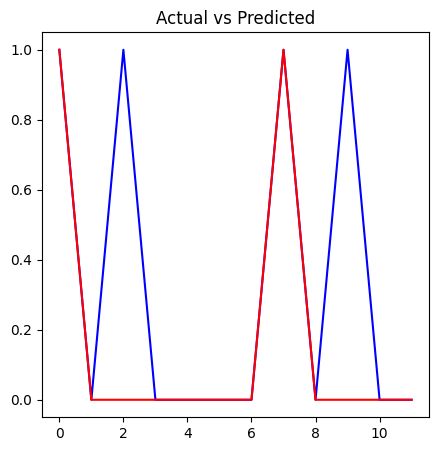

In [30]:
plt.figure(figsize=(5,5))
plt.plot(ytest, label='Actual', c='blue')
plt.plot(ypred_knn, label='Predicted', c='red')
plt.title('Actual vs Predicted')
plt.show()


##### (ii) Naive Baye's Model:

In [32]:
from sklearn.naive_bayes import GaussianNB

In [35]:
nb=GaussianNB()
nb.fit(xtrain,ytrain) #training


,priors,None
,var_smoothing,1e-09


In [38]:
ypred_nb=nb.predict(xtest) #testing

In [45]:
ypred_nb

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [40]:
print("NB ACCURACY:",accuracy_score(ytest,ypred_nb))
print("NB PRECISION:",precision_score(ytest,ypred_nb))

NB ACCURACY: 1.0
NB PRECISION: 1.0


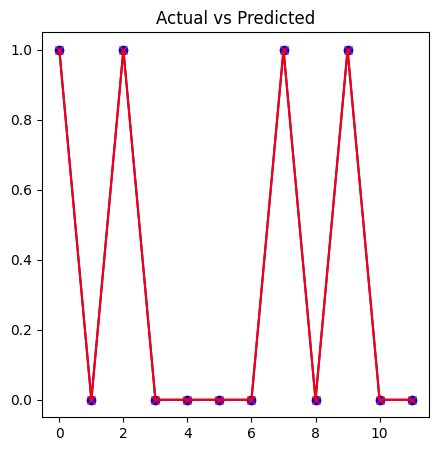

In [43]:
plt.figure(figsize=(5,5))
plt.plot(ytest, label='Actual', c='blue',marker='o')
plt.plot(ypred_nb, label='Predicted', c='red',marker='x')
plt.title('Actual vs Predicted')
plt.show()


##### (iii) Random Forest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf=RandomForestClassifier(n_estimators=700, criterion='entropy')

In [47]:
rf.fit(xtrain,ytrain) #training
ypred_rf=rf.predict(xtest) #testing

In [48]:
ypred_rf

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [49]:
print("RANDOM FOREST ACCURACY:",accuracy_score(ytest,ypred_rf))
print("RANDOM FOREST PRECISION:",precision_score(ytest,ypred_rf))

RANDOM FOREST ACCURACY: 1.0
RANDOM FOREST PRECISION: 1.0


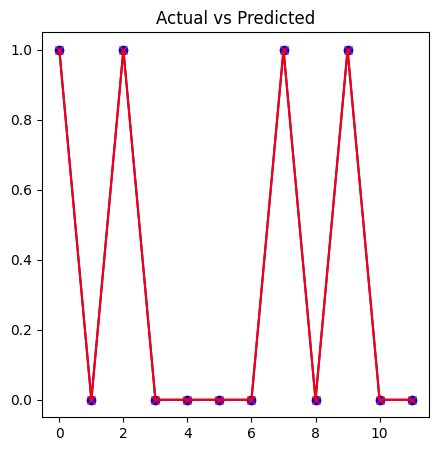

In [50]:
plt.figure(figsize=(5,5))
plt.plot(ytest, label='Actual', c='blue',marker='o')
plt.plot(ypred_rf, label='Predicted', c='red',marker='x')
plt.title('Actual vs Predicted')
plt.show()


##### (iv) Decision Tree Model

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dt=DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [54]:
dt.fit(xtrain,ytrain) #training

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
ypred_dt=dt.predict(xtest)

In [56]:
ypred_dt

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [57]:
print("DECISION TREE ACCURACY:",accuracy_score(ytest,ypred_dt))
print("DECISION TREE PRECISION:",precision_score(ytest,ypred_dt))

DECISION TREE ACCURACY: 1.0
DECISION TREE PRECISION: 1.0


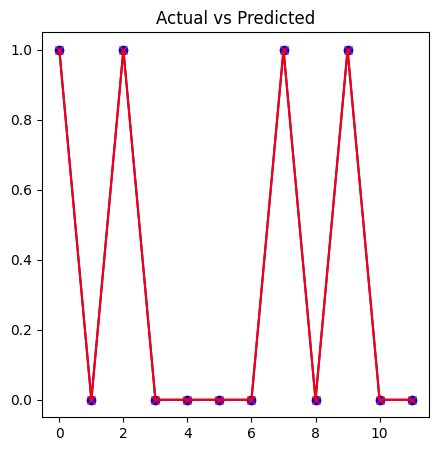

In [58]:
plt.figure(figsize=(5,5))
plt.plot(ytest, label='Actual', c='blue',marker='o')
plt.plot(ypred_dt, label='Predicted', c='red',marker='x')
plt.title('Actual vs Predicted')
plt.show()


##### (v) ANN model

In [62]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam


In [81]:
model=Sequential()
model.add(Dense(8,activation='relu',input_dim=4))
model.add(Dense(1,activation='sigmoid'))

C:\Users\user\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.compile(optimizer=Adam(learning_rate=0.01),loss='mse',metrics=['accuracy'])

In [83]:
X=np.array(x)
Y=np.array(y)

In [84]:
model.fit(X,Y,epochs=500) #training AND X was fetched from df.iloc[:,:-1].values and Y was fetched from df.iloc[:,-1].values

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4831 - loss: 0.5116
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5161 - loss: 0.4588
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5152 - loss: 0.44208
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5265 - loss: 0.4320
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4944 - loss: 0.43640
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5812 - loss: 0.35002
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5586 - loss: 0.3300
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6047 - loss: 0.3358
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6169 - loss: 0.3478
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.3003
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7698 - loss: 0.20536
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7567 - 

In [85]:
predictions=model.predict(X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step 


In [86]:
predictions

array([[7.79109716e-01],
       [9.96975124e-01],
       [3.86235304e-02],
       [5.59897353e-06],
       [9.99999285e-01],
       [7.62308403e-08],
       [2.65325980e-05],
       [1.41896331e-03],
       [1.18832672e-02],
       [9.99862611e-01],
       [3.48155027e-06],
       [2.82412628e-04],
       [1.53776328e-03],
       [9.99982655e-01],
       [9.99621212e-01],
       [3.29352915e-05],
       [9.99605358e-01],
       [2.90986293e-08],
       [9.99936283e-01],
       [9.99977410e-01],
       [9.99998569e-01],
       [1.27165622e-05],
       [8.00371708e-05],
       [4.16928437e-04],
       [1.00000000e+00],
       [2.77788006e-03],
       [9.96275060e-03],
       [2.42985266e-06],
       [9.99999583e-01],
       [9.99997437e-01],
       [7.52760395e-02],
       [9.99861598e-01],
       [1.00000000e+00],
       [9.99992967e-01],
       [6.40002836e-05],
       [2.27907458e-06],
       [9.99988735e-01],
       [9.99948084e-01],
       [1.60314030e-05],
       [4.14572477e-01],


In [87]:
predictions=np.round(predictions)

In [88]:
predictions

array([[1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.]], dtype=float32)

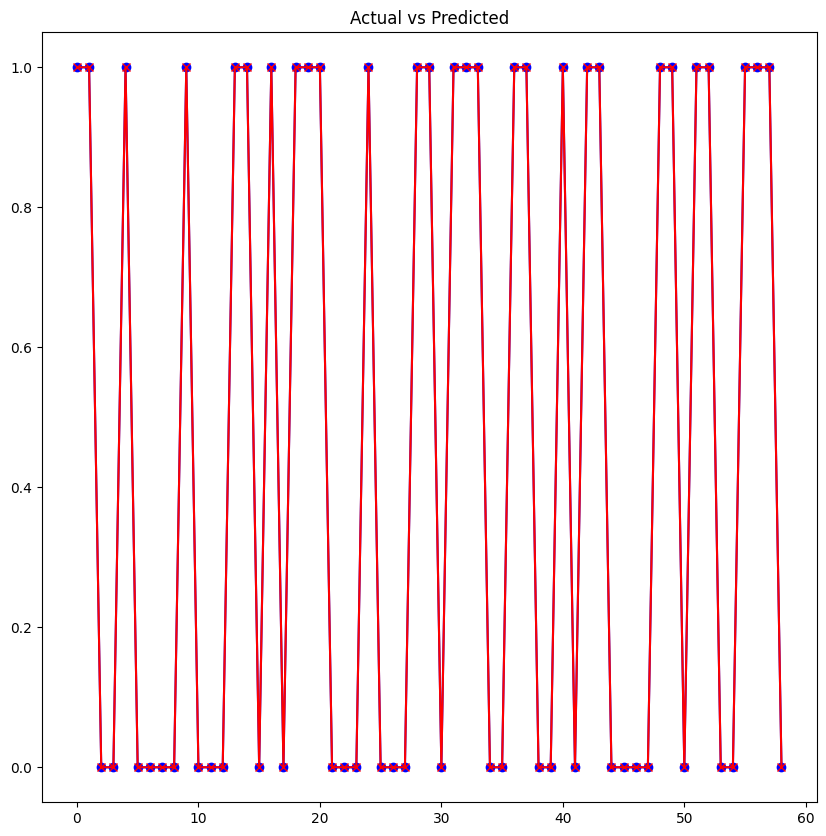

In [90]:
plt.figure(figsize=(10,10))
plt.plot(Y, label='Actual', c='blue',marker='o')
plt.plot(predictions, label='Predicted', c='red',marker='x')
plt.title('Actual vs Predicted')
plt.show()

##### From the above analysis it is concluded that :
        knn has an accuracy of 0.833333
        naive baye's has an accuracy of 1.0
        random forest has an accuracy of 1.0
        decision tree has an accuracy of 1.0 
        and ann predicts output predicts value very close to actual model by the graph plotted

        
